In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# 1. Φόρτωση των Log Returns (Χρησιμοποιούμε το Yahoo dataset)
log_returns = pd.read_csv('crypto_log_returns_yahoo.csv', index_col=0, parse_dates=True)
btc_returns = log_returns['BTC-USD'].dropna()

# 2. Scaling (x100)
# Πολλαπλασιάζουμε επί 100 για να βοηθήσουμε το GARCH να συγκλίνει (τα μοντέλα προτιμούν τιμές > 1)
scaled_returns = btc_returns * 100

# 3. Διαχωρισμός σε Train (80%) και Test (20%)
split_idx = int(len(scaled_returns) * 0.8)
train_data = scaled_returns.iloc[:split_idx]
test_data = scaled_returns.iloc[split_idx:]

print(f"Total Samples: {len(scaled_returns)}")
print(f"Train Samples: {len(train_data)}")
print(f"Test Samples:  {len(test_data)}")

Total Samples: 3046
Train Samples: 2436
Test Samples:  610


--- ADF Test Results ---
p-value: 0.0000e+00
Result: STATIONARY (Είμαστε ΟΚ)


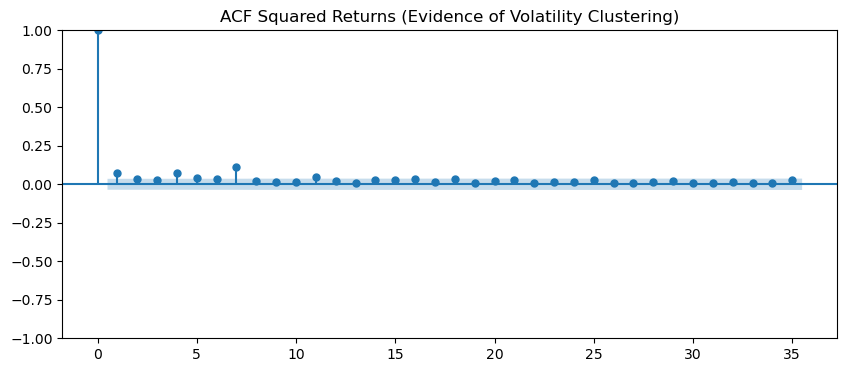

In [2]:
# 1. ADF Test (Έλεγχος Στασιμότητας)
# Αν p-value < 0.05, η σειρά είναι στάσιμη -> Κατάλληλη για GARCH
result = adfuller(scaled_returns)
print(f"--- ADF Test Results ---")
print(f"p-value: {result[1]:.4e}")
if result[1] < 0.05:
    print("Result: STATIONARY (Είμαστε ΟΚ)")
else:
    print("Result: NON-STATIONARY")

# 2. Έλεγχος Volatility Clustering
# Η αυτοσυσχέτιση στα τετράγωνα των αποδόσεων δείχνει ότι η μεταβλητότητα δεν είναι τυχαία
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(scaled_returns ** 2, ax=ax, title='ACF Squared Returns (Evidence of Volatility Clustering)')
plt.show()

In [3]:
print("--- Training ARIMA Model ---")
# Απλό μοντέλο ARIMA(1,0,1) για να βρούμε τη μέση τιμή
arima_model = ARIMA(train_data, order=(1, 0, 1))
arima_result = arima_model.fit()
print(arima_result.summary().tables[1]) # Εμφάνιση των συντελεστών

--- Training ARIMA Model ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0601      0.073      0.818      0.413      -0.084       0.204
ar.L1         -0.5852      0.181     -3.232      0.001      -0.940      -0.230
ma.L1          0.5350      0.187      2.856      0.004       0.168       0.902
sigma2        12.9873      0.137     94.630      0.000      12.718      13.256


--- Training GARCH(1,1) Model ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                BTC-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6443.25
Distribution:                  Normal   AIC:                           12894.5
Method:            Maximum Likelihood   BIC:                           12917.7
                                        No. Observations:                 2436
Date:                Tue, May 05 2026   Df Residuals:                     2435
Time:                        16:42:14   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.1274  6.97

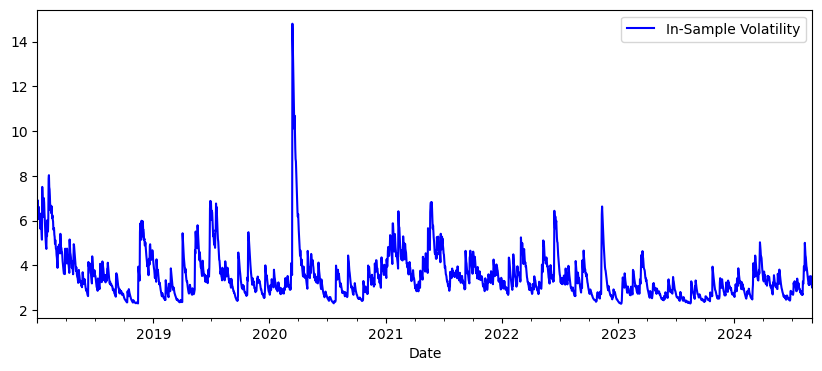

In [4]:
print("--- Training GARCH(1,1) Model ---")
# Constant Mean + GARCH Volatility
garch_model = arch_model(train_data, mean='Constant', vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

# Οπτικοποίηση της μεταβλητότητας στο Training set
fig, ax = plt.subplots(figsize=(10, 4))
garch_result.conditional_volatility.plot(ax=ax, color='blue', label='In-Sample Volatility')
plt.legend()
plt.show()

In [5]:
print("--- Training Hybrid ARIMA-GARCH ---")
# Mean='AR' (από το ARIMA) και Vol='Garch'
hybrid_model = arch_model(train_data, mean='AR', lags=1, vol='Garch', p=1, q=1)
hybrid_result = hybrid_model.fit(disp='off')
print(hybrid_result.summary())

--- Training Hybrid ARIMA-GARCH ---
                           AR - GARCH Model Results                           
Dep. Variable:                BTC-USD   R-squared:                       0.002
Mean Model:                        AR   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -6438.37
Distribution:                  Normal   AIC:                           12886.7
Method:            Maximum Likelihood   BIC:                           12915.7
                                        No. Observations:                 2435
Date:                Tue, May 05 2026   Df Residuals:                     2433
Time:                        16:42:15   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.1287  7.

In [6]:
# --- Forecasting με βάση Ημερομηνίες ---

# 1. Ορισμός Μοντέλου σε ΟΛΟ το dataset
full_model = arch_model(scaled_returns, mean='AR', lags=1, vol='Garch', p=1, q=1)

# 2. Εκπαίδευση (Fit) μέχρι το split_idx (last_obs)
res_full = full_model.fit(last_obs=split_idx, disp='off')

# 3. Πρόβλεψη (Forecast)
# Χρησιμοποιούμε την ΗΜΕΡΟΜΗΝΙΑ έναρξης του test set
start_date = test_data.index[0]
forecasts = res_full.forecast(horizon=1, start=start_date, align='target')

# 4. Εξαγωγή Προβλέψεων & Ευθυγράμμιση
# Παίρνουμε τη στήλη variance ('h.1')
pred_var_full = forecasts.variance['h.1']

# Κρατάμε ΑΥΣΤΗΡΑ μόνο τις ημερομηνίες που υπάρχουν στο Test Set
pred_var_test = pred_var_full.reindex(test_data.index)

# Υπολογισμός Volatility (ρίζα της διακύμανσης)
pred_volatility = np.sqrt(pred_var_test)

# Καθαρισμός από τυχόν NaN στην αρχή (αν υπάρχουν)
pred_volatility = pred_volatility.dropna()

# Ευθυγράμμιση του Test Data (ώστε να ταιριάζουν απόλυτα οι ημερομηνίες)
aligned_test_data = test_data.loc[pred_volatility.index]

print(f"Predictions Shape: {pred_volatility.shape}")
print(f"Test Data Shape:   {aligned_test_data.shape}")

Predictions Shape: (609,)
Test Data Shape:   (609,)



=== FINAL BENCHMARK RESULTS (TEST SET) ===
RMSE:  2.0713
MAE:   1.7786
QLIKE: 2.7530  (Baseline Score)


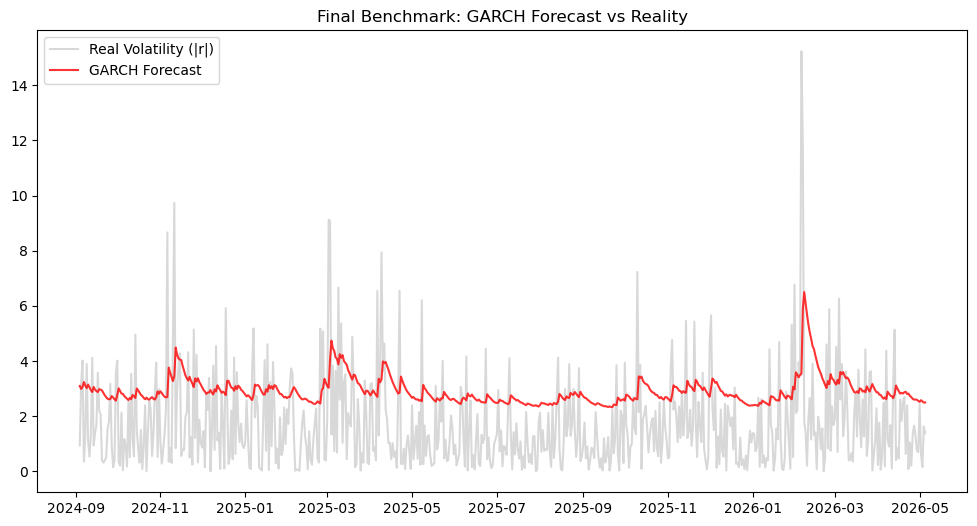

In [7]:
# --- Metrics ---

# Ground Truth: Απόλυτες αποδόσεις
aligned_true = np.abs(aligned_test_data)
aligned_pred = pred_volatility

# Έλεγχος ασφαλείας πριν τρέξουν τα metrics
if len(aligned_true) == len(aligned_pred) and len(aligned_pred) > 0:
    
    # [cite_start]1. RMSE & MAE [cite: 46, 47]
    rmse = np.sqrt(mean_squared_error(aligned_true, aligned_pred))
    mae = mean_absolute_error(aligned_true, aligned_pred)

    # [cite_start]2. QLIKE [cite: 49]
    # QLIKE = log(pred_var) + true_var / pred_var
    pred_v = aligned_pred ** 2
    true_v = aligned_test_data ** 2
    qlike = np.mean(np.log(pred_v) + true_v / pred_v)

    print("\n=== FINAL BENCHMARK RESULTS (TEST SET) ===")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"QLIKE: {qlike:.4f}  (Baseline Score)")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(aligned_true.index, aligned_true, color='grey', alpha=0.3, label='Real Volatility (|r|)')
    plt.plot(aligned_pred.index, aligned_pred, color='red', alpha=0.8, label='GARCH Forecast')
    plt.title('Final Benchmark: GARCH Forecast vs Reality')
    plt.legend()
    plt.show()

else:
    print("ΣΦΑΛΜΑ: Τα δεδομένα είναι κενά ή ανίσα. Έλεγξε το Cell 6.")


--- Multi-step Forecasting (Mean Reversion Analysis) ---
Πρόβλεψη 7ης μέρας (7-step ahead): 3.2815
Πρόβλεψη 30ης μέρας (30-step ahead): 3.6516


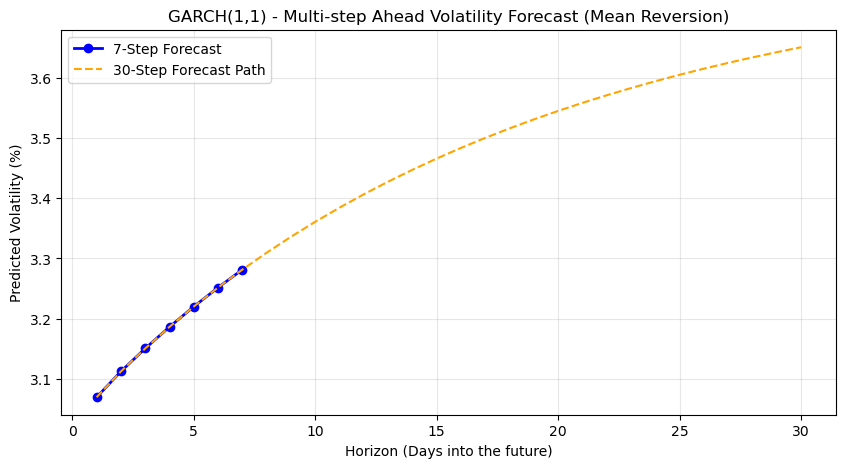

In [8]:
# --- 7-step & 30-step ahead Forecasting ---

print("\n--- Multi-step Forecasting (Mean Reversion Analysis) ---")

# Ζητάμε από το εκπαιδευμένο μοντέλο να προβλέψει 30 μέρες μπροστά (από το τέλος των δεδομένων)
long_term_forecasts = hybrid_result.forecast(horizon=30)

# Παίρνουμε την τελευταία γραμμή προβλέψεων (τα 30 μελλοντικά βήματα)
var_path = long_term_forecasts.variance.iloc[-1]
vol_path = np.sqrt(var_path)

# Διαχωρισμός σε 7-step και 30-step για ανάλυση
vol_7_step = vol_path[:7]
vol_30_step = vol_path

print(f"Πρόβλεψη 7ης μέρας (7-step ahead): {vol_7_step.iloc[-1]:.4f}")
print(f"Πρόβλεψη 30ης μέρας (30-step ahead): {vol_30_step.iloc[-1]:.4f}")

# Οπτικοποίηση του φαινομένου Mean Reversion
plt.figure(figsize=(10, 5))
plt.plot(range(1, 8), vol_7_step, marker='o', color='blue', linewidth=2, label='7-Step Forecast')
plt.plot(range(1, 31), vol_30_step, linestyle='--', color='orange', label='30-Step Forecast Path')

plt.title('GARCH(1,1) - Multi-step Ahead Volatility Forecast (Mean Reversion)')
plt.xlabel('Horizon (Days into the future)')
plt.ylabel('Predicted Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()